
# Machine Learning — Notebook 05  
## Regresión logística: probabilidad, log-loss, matriz de confusión y calibración

### Objetivos
- Entender la regresión logística como modelo de **probabilidad**:
  $$
  p(x)=P(y=1\mid x)=\sigma(\beta_0+\beta^\top x)
  $$
- Entrenar un modelo logístico y evaluar:
  - **log-loss (cross-entropy)**,
  - **matriz de confusión** y métricas por umbral,
  - **ROC/PR** (como referencia).
- Introducir **calibración**:
  - curva de calibración (reliability diagram),
  - **Brier score**.
- Practicar selección de **umbral según costos** (FP vs FN).

> En este notebook usaremos datos simulados para controlar: desbalance, separabilidad y calibración.



---
## 0) Setup


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    log_loss, brier_score_loss, roc_curve, precision_recall_curve
)

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.dummy import DummyClassifier

RANDOM_STATE = 7
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)



---
## 1) Modelo logístico: probabilidades y log-loss

La regresión logística modela una probabilidad mediante una sigmoide:

$$
\sigma(z)=\frac{1}{1+e^{-z}},\qquad p_i=\sigma(\beta_0+\beta^\top x_i)
$$

La función de pérdida típica (a minimizar) es **log-loss** (cross-entropy):

$$
\mathcal{L}(\beta)=-\frac{1}{n}\sum_{i=1}^n \left[y_i\log(p_i) + (1-y_i)\log(1-p_i)\right]
$$

- Castiga fuerte cuando el modelo está “muy seguro” y se equivoca.
- Evalúa la calidad de probabilidades, no solo aciertos.



---
## 2) Dataset simulado (binario) con desbalance

Simulamos un problema con:
- 6 features (algunas informativas),
- desbalance (pocos positivos),
- probabilidades verdaderas $p_{true}$.

Así podremos comparar baseline vs logística y evaluar log-loss y calibración.


In [2]:

# 2.1 Simulación
n = 4000
p = 6

X = rng.normal(size=(n, p))
w = np.array([1.4, -2.0, 0.0, 0.7, 0.0, 1.0])
logits = -2.0 + X @ w + rng.normal(0, 0.7, size=n)  # intercepto negativo => desbalance
p_true = 1 / (1 + np.exp(-logits))
y = rng.binomial(1, p_true)

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

y_train.mean(), y_test.mean()


(np.float64(0.2773333333333333), np.float64(0.277))

In [3]:
X

array([[ 1.23015336e-03,  2.98745538e-01, -2.74137855e-01,
        -8.90591839e-01, -4.54670785e-01, -9.91646555e-01],
       [ 6.01436026e-02,  1.34021525e+00, -4.92206519e-01,
        -6.20474900e-01,  4.89842050e-01,  3.56887008e-01],
       [ 1.05414249e-01, -9.30468045e-01, -2.92518225e-02,
         6.95303194e-01, -1.34421455e+00, -4.57615761e-01],
       ...,
       [ 6.86328180e-01,  3.37945854e-01,  1.22110763e+00,
         2.30980435e+00,  8.72944697e-01,  5.86897692e-01],
       [ 2.03091787e-01,  8.77667904e-01,  1.41868796e+00,
        -2.79570524e-01, -1.28733864e+00, -1.38449865e+00],
       [ 1.02659120e+00,  4.85146003e-01,  5.56434423e-01,
        -1.71010083e+00, -5.68111860e-01, -1.58451056e+00]])

---
---

## 2) **O de pronto**.... Dataset **NO** simulado (binario) con desbalance

Si quieres dataset simulado no corras estas celdas y salta hasta 3)....


In [4]:

# Carseats (ISLR) desde Rdatasets
url_carseats = "https://vincentarelbundock.github.io/Rdatasets/csv/ISLR/Carseats.csv"
car = pd.read_csv(url_carseats)

# Algunas fuentes añaden una columna índice (p.ej. 'Unnamed: 0' o 'rownames').
for col in ["Unnamed: 0", "rownames"]:
    if col in car.columns:
        car = car.drop(columns=[col])

car.head()


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [5]:

car.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


In [6]:
# Define the mapping
mapping = {'Bad': 0, 'Medium': 1, 'Good': 2}

# Apply the mapping
car["ShelveLoc_Num"] = car["ShelveLoc"].map(mapping)
car.drop(["ShelveLoc","Urban","US"], axis=1, inplace=True)


In [7]:

# Objetivo binario: HighSales (1 si Sales > 8)
car["HighSales"] = (car["Sales"] > 8).astype(int)
car = car.drop(columns=["Sales"])

X = car.drop(columns=["HighSales"])
y = car["HighSales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=123, stratify=y
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=123, stratify=y_train
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)


(HighSales
 0    0.59
 1    0.41
 Name: proportion, dtype: float64,
 HighSales
 0    0.59
 1    0.41
 Name: proportion, dtype: float64)

In [8]:
X_train

,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Num
384,123,37,15,348,112,28,12,2
267,134,82,7,473,112,51,12,0
49,157,93,0,51,149,32,17,2
218,138,61,12,156,120,25,14,1
367,95,106,0,256,53,52,17,2
...,...,...,...,...,...,...,...,...
325,144,69,11,131,104,47,11,1
157,121,58,8,249,90,48,13,1
30,125,94,0,447,89,30,12,2
272,113,33,0,14,63,38,12,2


---
---
## 3) Baseline vs Logistic Regression (pipeline con escalado)

La logística es sensible a escala → usamos `StandardScaler` en un `Pipeline`.


In [9]:

# Baseline: clase mayoritaria (produce probas constantes)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
p_dummy = dummy.predict_proba(X_test)[:, 1]

# Logistic Regression + escalado
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=5000))
])
pipe_lr.fit(X_train, y_train)
p_lr = pipe_lr.predict_proba(X_test)[:, 1]

def prob_metrics(y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    cm = confusion_matrix(y_true, pred)
    return {
        "LogLoss": log_loss(y_true, np.c_[1-proba, proba]),
        "Brier": brier_score_loss(y_true, proba),
        "ROC_AUC": roc_auc_score(y_true, proba),
        "PR_AUC": average_precision_score(y_true, proba),
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "TP": cm[1,1], "FP": cm[0,1], "FN": cm[1,0], "TN": cm[0,0],
    }

pd.DataFrame([
    prob_metrics(y_test, p_dummy),
    prob_metrics(y_test, p_lr),
], index=["Dummy(most_frequent)", "LogReg (scaled)"])


,LogLoss,Brier,ROC_AUC,PR_AUC,Accuracy,Precision,Recall,F1,TP,FP,FN,TN
Dummy(most_frequent),14.777898,0.410000,0.5000,0.4100,0.59,0.000000,0.000000,0.000000,0,0,41,59
LogReg (scaled),0.269726,0.077688,0.9537,0.9534,0.90,0.918919,0.829268,0.871795,34,3,7,56



---
## 4) Matriz de confusión y efecto del umbral $\tau$

Usamos:
$$
\hat{y}=\mathbf{1}[p(y=1\mid x)\ge \tau]
$$

Cambiar $\tau$ cambia el trade-off entre **FN** y **FP**.


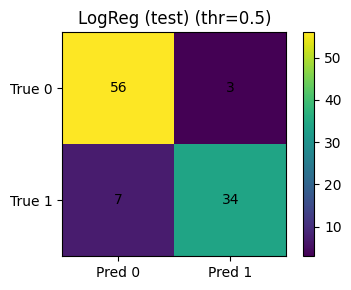

array([[56,  3],
       [ 7, 34]])

In [10]:

def show_confusion(y_true, proba, thr=0.5, title="Confusion Matrix"):
    pred = (proba >= thr).astype(int)
    cm = confusion_matrix(y_true, pred)
    plt.figure(figsize=(4,3))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title + f" (thr={thr})")
    plt.colorbar()
    plt.xticks([0,1], ["Pred 0", "Pred 1"])
    plt.yticks([0,1], ["True 0", "True 1"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()
    return cm

show_confusion(y_test, p_lr, thr=0.5, title="LogReg (test)")


In [11]:

thresholds = np.linspace(0.05, 0.95, 19)
rows = []
for t in thresholds:
    rep = prob_metrics(y_test, p_lr, thr=float(t))
    rep["thr"] = float(t)
    rows.append(rep)

thr_df = pd.DataFrame(rows).set_index("thr")[["Precision","Recall","F1","Accuracy","FP","FN"]]
thr_df.head()


,Precision,Recall,F1,Accuracy,FP,FN
thr,,,,,,
0.05,0.512821,0.97561,0.672269,0.61,38,1
0.10,0.563380,0.97561,0.714286,0.68,31,1
0.15,0.615385,0.97561,0.754717,0.74,25,1
0.20,0.666667,0.97561,0.792079,0.79,20,1
0.25,0.722222,0.95122,0.821053,0.83,15,2


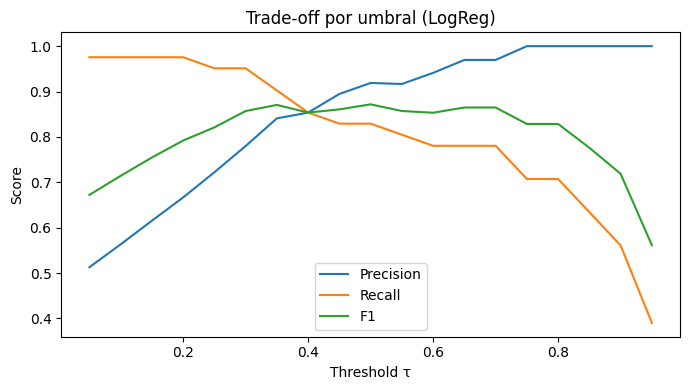

In [12]:

plt.figure(figsize=(7,4))
plt.plot(thr_df.index, thr_df["Precision"], label="Precision")
plt.plot(thr_df.index, thr_df["Recall"], label="Recall")
plt.plot(thr_df.index, thr_df["F1"], label="F1")
plt.xlabel("Threshold τ")
plt.ylabel("Score")
plt.title("Trade-off por umbral (LogReg)")
plt.legend()
plt.tight_layout()
plt.show()



---
## 5) ROC y PR curves (referencia)

- ROC: TPR vs FPR (AUC resume separación global).
- PR: Precision vs Recall (más informativa con clase positiva rara).


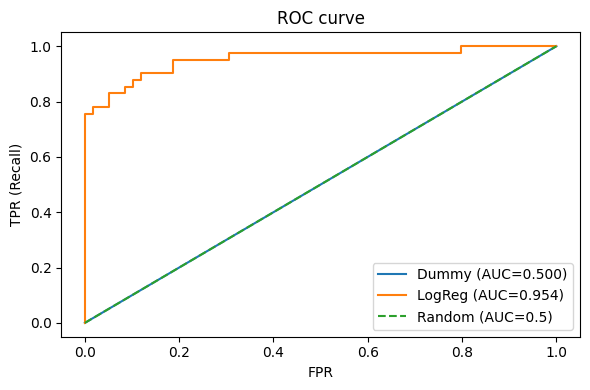

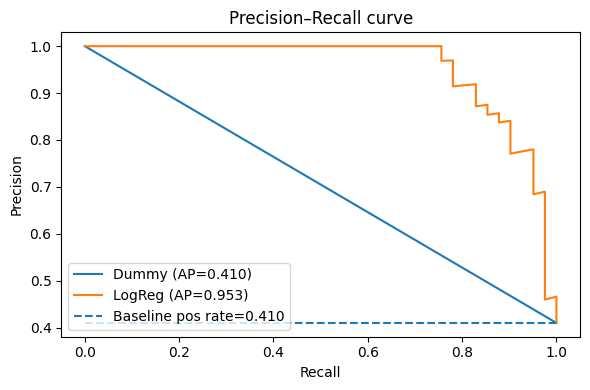

In [13]:

# ROC
plt.figure(figsize=(6,4))
for name, proba in [("Dummy", p_dummy), ("LogReg", p_lr)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--", label="Random (AUC=0.5)")
plt.xlabel("FPR")
plt.ylabel("TPR (Recall)")
plt.title("ROC curve")
plt.legend()
plt.tight_layout()
plt.show()

# PR
plt.figure(figsize=(6,4))
for name, proba in [("Dummy", p_dummy), ("LogReg", p_lr)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
baseline = y_test.mean()
plt.hlines(baseline, 0, 1, linestyles="--", label=f"Baseline pos rate={baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve")
plt.legend()
plt.tight_layout()
plt.show()



---
## 6) Calibración: ¿las probabilidades significan lo que dicen?

Un modelo está bien calibrado si, por ejemplo:
> entre los casos donde el modelo predice 0.8, ~80% son realmente positivos.

### Curva de calibración
Agrupamos predicciones en bins y comparamos:
- x: probabilidad media predicha
- y: fracción real de positivos

### Brier score
$$
\text{Brier}=\frac{1}{n}\sum_{i=1}^n (y_i-p_i)^2
$$
Más bajo es mejor.


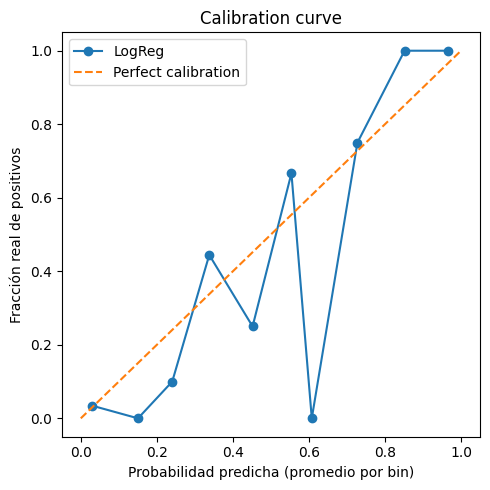

Brier score: 0.07768845126880972


In [14]:

# Curva de calibración (LogReg)
frac_pos, mean_pred = calibration_curve(y_test, p_lr, n_bins=10, strategy="uniform")

plt.figure(figsize=(5,5))
plt.plot(mean_pred, frac_pos, marker="o", label="LogReg")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.xlabel("Probabilidad predicha (promedio por bin)")
plt.ylabel("Fracción real de positivos")
plt.title("Calibration curve")
plt.legend()
plt.tight_layout()
plt.show()

print("Brier score:", brier_score_loss(y_test, p_lr))



### Calibración con `CalibratedClassifierCV` (opcional)

Calibramos LogReg con `sigmoid` (Platt scaling) usando CV interna.


In [15]:

base_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=5000))
])

cal_lr = CalibratedClassifierCV(base_lr, method="sigmoid", cv=5)
cal_lr.fit(X_train, y_train)

p_cal = cal_lr.predict_proba(X_test)[:, 1]

pd.DataFrame([
    {"Model":"LogReg", "Brier": brier_score_loss(y_test, p_lr), "LogLoss": log_loss(y_test, np.c_[1-p_lr, p_lr])},
    {"Model":"Calibrated(LogReg)", "Brier": brier_score_loss(y_test, p_cal), "LogLoss": log_loss(y_test, np.c_[1-p_cal, p_cal])},
]).set_index("Model")


,Brier,LogLoss
Model,,
LogReg,0.077688,0.269726
Calibrated(LogReg),0.081203,0.282549


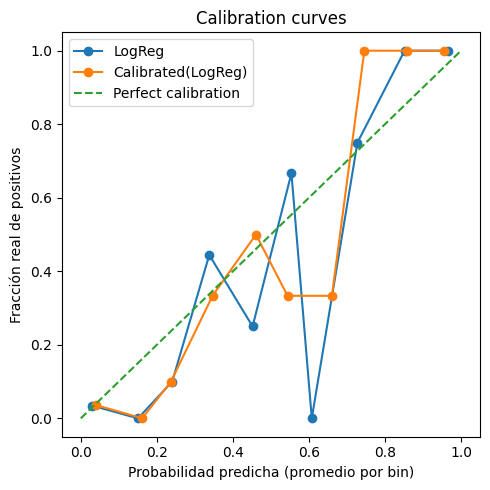

In [16]:

frac_pos1, mean_pred1 = calibration_curve(y_test, p_lr, n_bins=10, strategy="uniform")
frac_pos2, mean_pred2 = calibration_curve(y_test, p_cal, n_bins=10, strategy="uniform")

plt.figure(figsize=(5,5))
plt.plot(mean_pred1, frac_pos1, marker="o", label="LogReg")
plt.plot(mean_pred2, frac_pos2, marker="o", label="Calibrated(LogReg)")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.xlabel("Probabilidad predicha (promedio por bin)")
plt.ylabel("Fracción real de positivos")
plt.title("Calibration curves")
plt.legend()
plt.tight_layout()
plt.show()



---
## 7) Selección de umbral según costos (FP vs FN)

Supón costos:
- $C_{FN}$: costo de un falso negativo (perder un positivo real).
- $C_{FP}$: costo de un falso positivo (falsa alarma).

Criterio simple:
$$
\text{Cost}(\tau)=C_{FP}\cdot FP(\tau)+C_{FN}\cdot FN(\tau)
$$

> En práctica, seleccionar $\tau$ usando **validation**, no test.


In [17]:

def cost_for_thresholds(y_true, proba, thresholds, c_fp=1.0, c_fn=5.0):
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        cm = confusion_matrix(y_true, pred)
        fp = cm[0,1]
        fn = cm[1,0]
        cost = c_fp*fp + c_fn*fn
        rows.append({"thr": float(t), "FP": fp, "FN": fn, "Cost": cost})
    return pd.DataFrame(rows).set_index("thr")

thresholds = np.linspace(0.05, 0.95, 37)

df_cost = cost_for_thresholds(y_test, p_lr, thresholds, c_fp=1.0, c_fn=10.0)
df_cost.sort_values("Cost").head(10)


,FP,FN,Cost
thr,,,
0.200,20,1,30.0
0.300,11,2,31.0
0.175,23,1,33.0
0.275,14,2,34.0
0.150,25,1,35.0
0.250,15,2,35.0
0.225,16,2,36.0
0.100,31,1,41.0
0.125,31,1,41.0


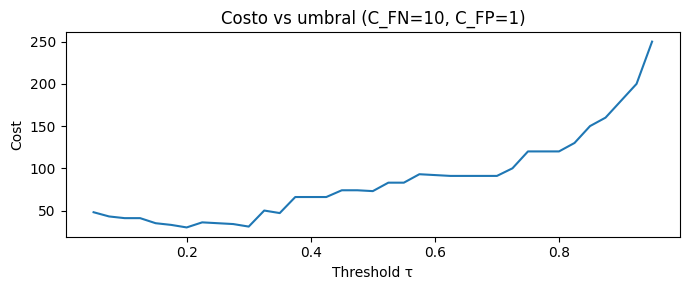

In [18]:

plt.figure(figsize=(7,3))
plt.plot(df_cost.index, df_cost["Cost"])
plt.xlabel("Threshold τ")
plt.ylabel("Cost")
plt.title("Costo vs umbral (C_FN=10, C_FP=1)")
plt.tight_layout()
plt.show()



---
## 8) Ejercicios (Semana 5)

### Ejercicio 1 — Log-loss vs Accuracy
1) Reporta Accuracy y LogLoss para baseline y LogReg.  
2) Explica por qué un modelo puede tener buena accuracy pero mal log-loss.

### Ejercicio 2 — Calibración
1) Grafica la curva de calibración para LogReg. ¿Dónde sobre/sub-estima?  
2) ¿Mejora Brier al calibrar con `sigmoid`? ¿Y el log-loss?

### Ejercicio 3 — Umbral por costo
1) Encuentra el mejor $\tau$ para (a) $C_{FN}=10, C_{FP}=1$ y (b) $C_{FN}=1, C_{FP}=10$.  
2) Explica cuál escenario corresponde a: fraude, spam y salud.

### Ejercicio 4 — Desbalance y PR-AUC
1) ¿Por qué PR-AUC suele ser más informativa que ROC-AUC cuando hay pocos positivos?  
2) Si duplicas el desbalance (menos positivos), ¿qué cambia en PR baseline?
